In [1]:
import numpy as np
import tifffile as tiff

import matplotlib.pyplot as plt

In [2]:
ch00 = tiff.imread("data/WGA_GFP_DAPI/Project_BLOCCO_1_ch00.tif")
ch01 = tiff.imread("data/WGA_GFP_DAPI/Project_BLOCCO_1_ch01.tif")
ch02 = tiff.imread("data/WGA_GFP_DAPI/Project_BLOCCO_1_ch02.tif")

In [3]:
import tifffile as tiff

In [47]:
import tifffile as tiff
import numpy as np

for i in [1,2,3,4,5,6,7,9]:
    ch00 = tiff.imread(f"data/WGA_GFP_DAPI/Project_BLOCCO_{i}_ch00.tif")
    ch01 = tiff.imread(f"data/WGA_GFP_DAPI/Project_BLOCCO_{i}_ch01.tif")
    ch02 = tiff.imread(f"data/WGA_GFP_DAPI/Project_BLOCCO_{i}_ch02.tif")
    
    rgb = np.stack([
      ch02[:, :, 0],  # R
      ch01[:, :, 1],  # G
      ch00[:, :, 2],  # B
    ], axis=-1)
    
    tiff.imwrite(f"data/WGA_GFP_DAPI/RGB/Project_BLOCCO_{i}.tif", rgb)

In [48]:
rgb = tiff.imread("data/WGA_GFP_DAPI/RGB/Project_BLOCCO_1.tif")

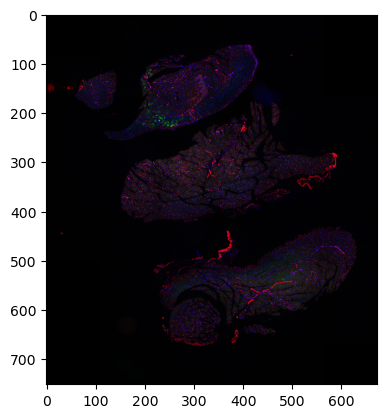

In [49]:
plt.imshow(rgb[::16, ::16, :])

In [ ]:
# SEGMENTATION WITH CELLPOSE!

In [6]:
segm = tiff.imread("data/WGA_GFP_DAPI/CellPose/Project_BLOCCO_1_masks.tif") 

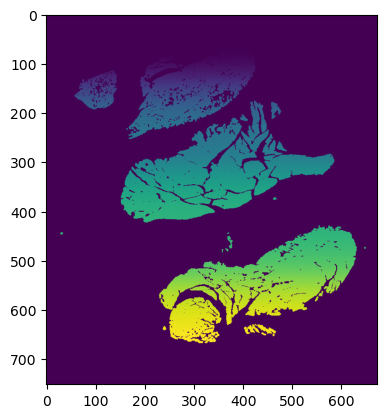

In [7]:
plt.imshow(segm[::16, ::16])

In [28]:
segm = tiff.imread("data/CellPose/Project_BLOCCO_1_ch00.tif") 

In [29]:
import cv2
import numpy as np
from skimage.morphology import remove_small_objects, remove_small_holes, disk, closing, dilation
from skimage.measure import label, regionprops
from scipy import ndimage as ndi
import numpy as np
from skimage.measure import regionprops

# fiber_mask: binary image, True/1 where fibers are segmented
fiber_mask = segm.astype(bool)

# 1. Remove tiny noisy fiber fragments
clean = remove_small_objects(fiber_mask, max_size=50)

# 2. Dilate or close fibers so nearby fibers within the same tissue merge
# Increase radius if fibers inside one tissue are far apart
merged = closing(clean, disk(10))
merged = dilation(merged, disk(8))

# 3. Fill holes inside tissue regions
filled = ndi.binary_fill_holes(merged)
filled = remove_small_holes(filled, max_size=2000)

# 4. Label connected tissue candidates
labels = label(filled)

# 5. Keep the 3 largest components, assuming you expect exactly 3 tissues
regions = regionprops(labels)
regions = sorted(regions, key=lambda r: r.area, reverse=True)

tissue_mask = np.zeros_like(labels, dtype=np.uint8)

for i, region in enumerate(regions[:3], start=1):
    tissue_mask[labels == region.label] = i

boxes = []

for region in regionprops(tissue_mask):
    min_row, min_col, max_row, max_col = region.bbox

    boxes.append({
        "label": region.label,
        "x1": min_col,
        "y1": min_row,
        "x2": max_col,
        "y2": max_row,
        "area": region.area
    })



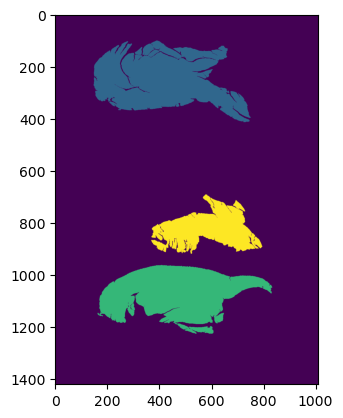

In [30]:
plt.imshow(tissue_mask[::16, ::16])

In [27]:
print(boxes)

[{'label': 1, 'x1': 1740, 'y1': 488, 'x2': 6452, 'y2': 4172, 'area': 10646943.0}, {'label': 2, 'x1': 2328, 'y1': 7196, 'x2': 6400, 'y2': 8920, 'area': 3791040.0}, {'label': 3, 'x1': 2944, 'y1': 4560, 'x2': 6444, 'y2': 6360, 'area': 2292798.0}]


[{'label': 1, 'x1': 2416, 'y1': 2792, 'x2': 9376, 'y2': 6780, 'area': 12145804.0}, {'label': 2, 'x1': 3656, 'y1': 6852, 'x2': 10100, 'y2': 10708, 'area': 11801116.0}, {'label': 3, 'x1': 2652, 'y1': 1008, 'x2': 6816, 'y2': 4072, 'area': 6743271.0}]


In [134]:
import tifffile as tiff
import numpy as np
import cv2
import itertools
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    disk,
    binary_closing,
    binary_dilation,
    binary_erosion
)
from skimage.measure import label, regionprops


DS = 16

he_fiber_seg_full = tiff.imread("data/CellPose/Project_BLOCCO_1_ch00.tif")
dapi_fiber_seg_full = tiff.imread("data/WGA_GFP_DAPI/CellPose/Project_BLOCCO_1_masks.tif")

he_fiber_seg = he_fiber_seg_full[::DS, ::DS]
dapi_fiber_seg = dapi_fiber_seg_full[::DS, ::DS]

print("H&E full:", he_fiber_seg_full.shape)
print("DAPI full:", dapi_fiber_seg_full.shape)
print("H&E downsampled:", he_fiber_seg.shape)
print("DAPI downsampled:", dapi_fiber_seg.shape)

H&E full: (22718, 16166)
DAPI full: (12025, 10746)
H&E downsampled: (1420, 1011)
DAPI downsampled: (752, 672)


In [121]:
import numpy as np
from scipy import ndimage as ndi
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    disk,
    closing,
    dilation,
    erosion
)
from skimage.measure import label, regionprops


def get_tissue_mask_and_boxes(
    segm,
    n_tissues=3,
    min_fiber_size=10,
    closing_radius=5,
    dilation_radius=2,
    erosion_radius=1,
    hole_area=1000,
    min_tissue_area=100,
    keep_components=10,
    attach_small_components=True
):
    fiber_mask = segm.astype(bool)

    clean = remove_small_objects(
        fiber_mask,
        max_size=min_fiber_size
    )

    merged = closing(
        clean,
        footprint=disk(closing_radius)
    )

    merged = dilation(
        merged,
        footprint=disk(dilation_radius)
    )

    filled = ndi.binary_fill_holes(merged)

    filled = remove_small_holes(
        filled,
        max_size=hole_area
    )

    if erosion_radius > 0:
        filled = erosion(
            filled,
            footprint=disk(erosion_radius)
        )

    filled = remove_small_objects(
        filled,
        max_size=min_tissue_area
    )

    labels = label(filled)
    regions = regionprops(labels)
    regions = sorted(regions, key=lambda r: r.area, reverse=True)

    # Tenere più di 3 componenti candidate
    regions_keep = regions[:keep_components]

    candidate_mask = np.zeros_like(labels, dtype=np.int32)

    for i, region in enumerate(regions_keep, start=1):
        candidate_mask[labels == region.label] = i

    candidate_regions = regionprops(candidate_mask)
    candidate_regions = sorted(candidate_regions, key=lambda r: r.area, reverse=True)

    # I primi 3 diventano i tessuti principali
    main_regions = candidate_regions[:n_tissues]
    small_regions = candidate_regions[n_tissues:]

    tissue_mask = np.zeros_like(candidate_mask, dtype=np.uint8)

    main_centroids = []

    for new_label, region in enumerate(main_regions, start=1):
        tissue_mask[candidate_mask == region.label] = new_label
        cy, cx = region.centroid
        main_centroids.append([cy, cx])

    main_centroids = np.array(main_centroids)

    # Le componenti piccole vengono attaccate al tessuto principale più vicino
    if attach_small_components and len(small_regions) > 0:
        for region in small_regions:
            cy, cx = region.centroid
            dists = np.sqrt(
                (main_centroids[:, 0] - cy) ** 2 +
                (main_centroids[:, 1] - cx) ** 2
            )

            nearest_main_label = int(np.argmin(dists)) + 1
            tissue_mask[candidate_mask == region.label] = nearest_main_label

    # Rimuovi alla fine le componenti con area minore di questa soglia
    min_final_component_area = 100

    cleaned_tissue_mask = np.zeros_like(tissue_mask, dtype=np.uint8)

    for tissue_id in np.unique(tissue_mask):
        if tissue_id == 0:
            continue

        tissue_binary = tissue_mask == tissue_id
        tissue_cc = label(tissue_binary)

        for comp in regionprops(tissue_cc):
            if comp.area >= min_final_component_area:
                cleaned_tissue_mask[tissue_cc == comp.label] = tissue_id

    tissue_mask = cleaned_tissue_mask

    boxes = []

    for region in regionprops(tissue_mask):
        min_row, min_col, max_row, max_col = region.bbox
        cy, cx = region.centroid

        boxes.append({
            "label": region.label,
            "x1": min_col,
            "y1": min_row,
            "x2": max_col,
            "y2": max_row,
            "cx": cx,
            "cy": cy,
            "area": region.area
        })

    return tissue_mask, boxes

In [122]:
%%time

he_tissue_mask, he_boxes = get_tissue_mask_and_boxes(
    he_fiber_seg,
    n_tissues=3,
    min_fiber_size=10,
    closing_radius=5,
    dilation_radius=2,
    erosion_radius=0,
    hole_area=100,
    min_tissue_area=50,
    keep_components=10,
    attach_small_components=True
)

dapi_tissue_mask, dapi_boxes = get_tissue_mask_and_boxes(
    dapi_fiber_seg,
    n_tissues=3,
    min_fiber_size=10,
    closing_radius=5,
    dilation_radius=2,
    erosion_radius=0,
    hole_area=100,
    min_tissue_area=50,
    keep_components=10,
    attach_small_components=True
)

CPU times: user 238 ms, sys: 7.17 ms, total: 245 ms
Wall time: 243 ms


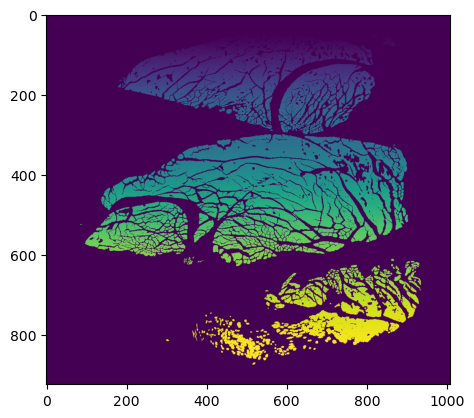

In [123]:
plt.imshow(he_fiber_seg)

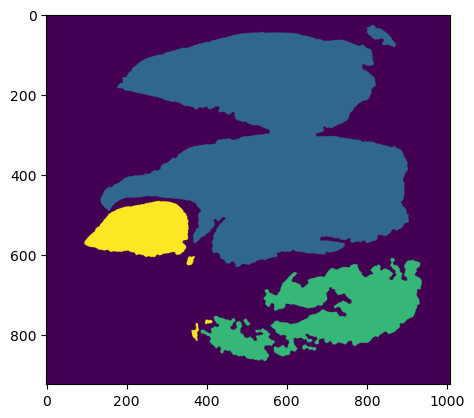

In [124]:
plt.imshow(he_tissue_mask)

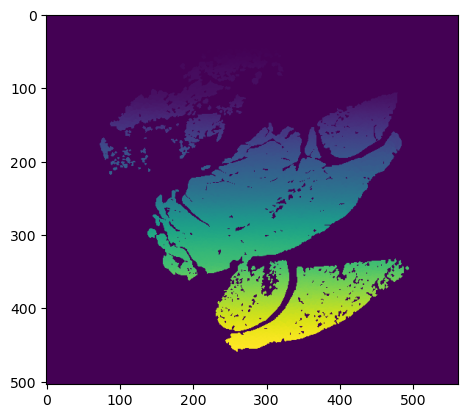

In [125]:
plt.imshow(dapi_fiber_seg)

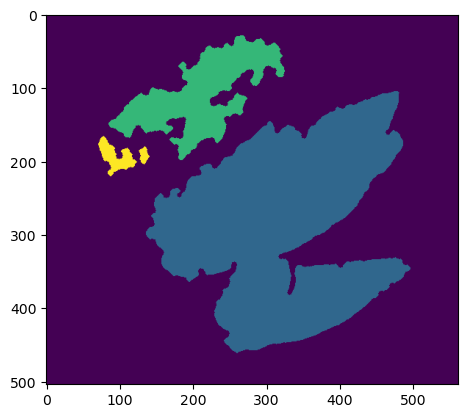

In [126]:
plt.imshow(dapi_tissue_mask)

In [147]:
def rotate_image_bound(image, angle, border_value=0, interpolation=cv2.INTER_LINEAR):
    h, w = image.shape[:2]
    center = (w / 2, h / 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    cos = abs(M[0, 0])
    sin = abs(M[0, 1])

    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    rotated = cv2.warpAffine(
        image,
        M,
        (new_w, new_h),
        flags=interpolation,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=border_value
    )

    return rotated

import cv2

def scale_image(image, scale):
    h, w = image.shape[:2]

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    return resized

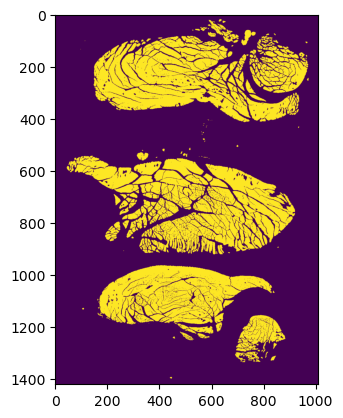

In [157]:
plt.imshow(he_fiber_seg > 0)

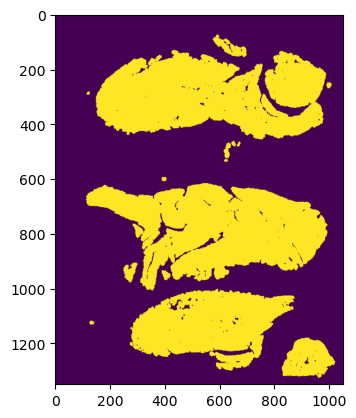

In [156]:
plt.imshow()

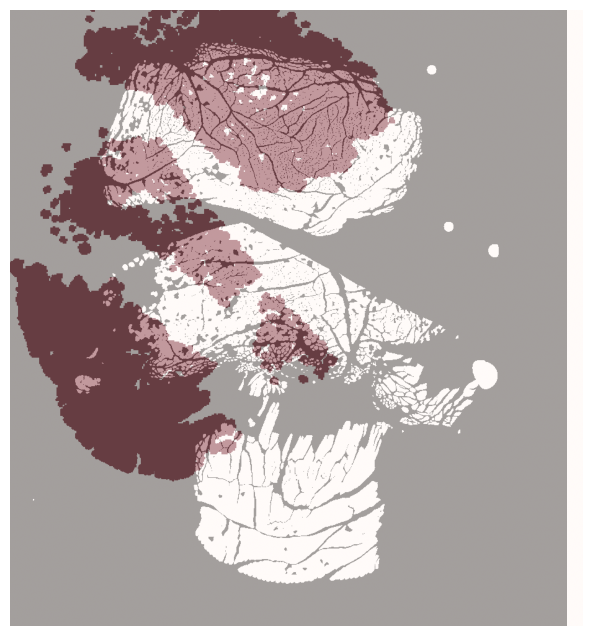

In [172]:
import matplotlib.pyplot as plt


DS = 16

he_fiber_seg_full = tiff.imread("data/CellPose/Project_BLOCCO_4_ch00.tif")
dapi_fiber_seg_full = tiff.imread("data/WGA_GFP_DAPI/CellPose/Project_BLOCCO_4_masks.tif")

he_fiber_seg = he_fiber_seg_full[::DS, ::DS]
dapi_fiber_seg = dapi_fiber_seg_full[::DS, ::DS]


# img1 e img2 sono binarie: True/False oppure 0/1
plt.figure(figsize=(8, 8))

img1 = he_fiber_seg > 0
img2 = scale_image(rotate_image_bound(dapi_fiber_seg, 155),2)[300:1600,320:1300] > 0
plt.imshow(img1, cmap="gray", alpha=0.6)
plt.imshow(img2, cmap="Reds", alpha=0.4)

plt.axis("off")
plt.show()